In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/mlx-2-0-regression/sample_submission.csv
/kaggle/input/competitions/mlx-2-0-regression/train.csv
/kaggle/input/competitions/mlx-2-0-regression/test.csv


In [2]:
train_df = pd.read_csv('/kaggle/input/competitions/mlx-2-0-regression/train.csv')
train_df

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,composition_label_0,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,...,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target
0,76339,0.482850,1.169231,80.018,0.020100,Country Stuff (feat. Jake Owen),1.0,0.789,154586.0,NaN,...,4.0,161853.0,7.0,4.0,NaN,0.607,7.0,0.7250,0.000000,74
1,80006,0.267862,1.321321,147.966,0.334000,Solitude,6.0,0.715,46874.0,15.0,...,4.0,155619.0,1.0,4.0,0.843,0.783,4.0,NaN,0.043200,2
2,83501,0.242606,1.285319,142.980,0.111000,BDFFRNT (Saved from Conformity),4.0,NaN,264665.0,7.0,...,4.0,209378.0,6.0,4.0,NaN,0.211,10.0,0.6020,0.000000,35
3,81530,0.426400,1.279435,123.063,0.196000,Headlights (feat. Ilsey),5.0,0.685,209208.0,5.0,...,4.0,219043.0,11.0,4.0,0.702,0.369,NaN,0.8200,0.000335,70
4,60534,0.000000,0.974906,132.722,0.081100,Afraid,6.0,0.856,215346.0,5.0,...,4.0,258893.0,1.0,0.0,0.000,0.631,1.0,0.0221,0.000000,78
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61604,75677,0.261387,0.809917,90.017,0.510000,Hasret,NaN,0.449,218490.0,43.0,...,4.0,183381.0,0.0,4.0,0.742,0.385,10.0,0.4610,0.000000,16
61605,29591,0.585648,1.185022,122.973,0.512000,NO HALO,NaN,0.573,259746.0,6.0,...,4.0,204533.0,4.0,4.0,0.869,0.470,9.0,0.7470,0.000170,69
61606,62355,0.112203,0.469714,121.045,0.493000,Aloha! - Main Title Theme,10.0,0.526,79093.0,66.0,...,4.0,157426.0,NaN,4.0,0.515,0.573,10.0,0.8190,0.101000,55
61607,88778,0.438699,1.486339,95.390,0.023700,Golden,NaN,0.838,208906.0,9.0,...,4.0,174000.0,4.0,4.0,0.676,0.254,8.0,0.7710,0.000131,88


In [3]:
test_df = pd.read_csv('/kaggle/input/competitions/mlx-2-0-regression/test.csv')
test_df

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,composition_label_0,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,...,emotional_resonance_2,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0
0,25174,0.600480,1.543590,124.008,0.0729,Dr.Q,1.0,0.763,23032.0,4.0,...,0.834,4.0,253987.0,4.0,4.0,0.604,0.2050,0.0,0.720,0.165000
1,38453,NaN,0.722420,129.942,0.0105,Start A Party,11.0,0.801,215466.0,20.0,...,0.216,4.0,267626.0,5.0,4.0,0.881,0.2610,1.0,0.496,0.000000
2,29013,0.461916,0.757962,83.000,0.2700,Sombras - Live,2.0,0.561,252261.0,44.0,...,0.546,4.0,226626.0,0.0,4.0,0.555,0.0555,0.0,0.846,0.002760
3,57463,0.144236,0.923977,183.991,0.1210,Tennis Court,2.0,NaN,198907.0,23.0,...,0.337,4.0,234286.0,0.0,4.0,0.674,0.4040,7.0,0.428,0.000194
4,51264,0.629832,1.473795,201.277,0.0610,La Cumbia Del Lazo,10.0,0.716,158720.0,NaN,...,0.966,4.0,188520.0,8.0,4.0,0.511,0.9620,10.0,0.652,0.000115
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41069,13950,0.272556,0.746250,110.001,0.0959,Best 4 U,5.0,0.608,239751.0,23.0,...,0.452,4.0,199849.0,10.0,4.0,0.655,0.3720,8.0,0.603,0.000000
41070,70306,0.434898,0.992874,135.984,0.0956,NaN,7.0,0.722,304290.0,15.0,...,0.666,4.0,368006.0,5.0,4.0,0.722,0.8300,6.0,0.653,0.000398
41071,30767,0.645150,1.551532,85.043,0.0288,Back from the Edge,10.0,0.726,234146.0,18.0,...,0.759,4.0,NaN,7.0,4.0,0.601,0.4740,10.0,0.850,NaN
41072,11188,0.576678,1.596491,79.227,0.2400,Pray For Us,2.0,0.842,59213.0,NaN,...,0.669,4.0,203346.0,5.0,4.0,0.487,0.0869,7.0,0.862,0.000068


In [4]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61609 entries, 0 to 61608
Data columns (total 62 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          61609 non-null  int64  
 1   emotional_charge_2          59167 non-null  float64
 2   groove_efficiency_1         61429 non-null  float64
 3   beat_frequency_1            61223 non-null  float64
 4   organic_texture_2           61226 non-null  float64
 5   composition_label_0         58660 non-null  object 
 6   harmonic_scale_1            58304 non-null  float64
 7   intensity_index_0           55638 non-null  float64
 8   duration_ms_0               60320 non-null  float64
 9   album_name_length           52015 non-null  float64
 10  beat_frequency_0            51878 non-null  float64
 11  beat_frequency_2            59843 non-null  float64
 12  artist_count                58348 non-null  float64
 13  composition_label_1         601

In [5]:
train_df.describe()

,id,emotional_charge_2,groove_efficiency_1,beat_frequency_1,organic_texture_2,harmonic_scale_1,intensity_index_0,duration_ms_0,album_name_length,beat_frequency_0,...,time_signature_0,duration_ms_1,harmonic_scale_0,time_signature_2,rhythmic_cohesion_2,emotional_resonance_0,harmonic_scale_2,intensity_index_2,instrumental_density_0,target
count,61609.000000,59167.000000,61429.000000,61223.000000,61226.000000,58304.000000,55638.000000,6.032000e+04,52015.000000,51878.000000,...,59704.000000,5.250400e+04,53925.000000,58455.000000,56049.000000,60063.000000,57142.000000,60916.000000,60900.000000,61609.000000
mean,51390.780162,0.316976,1.238856,121.022910,0.274748,5.192594,0.604426,2.011315e+05,18.225723,119.133973,...,3.874849,2.110477e+05,5.212499,3.901274,0.612252,0.458851,5.288894,0.616045,0.148391,52.067328
std,29659.344472,0.212777,6.171617,30.467061,0.303020,3.629153,0.243943,1.100738e+05,14.404713,32.067971,...,0.564558,8.911099e+04,3.571288,0.465295,0.179591,0.261196,3.567118,0.230109,0.306915,21.569248
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.485000e+03,1.000000,0.000000,...,0.000000,4.120000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,25832.000000,0.143877,0.730914,96.138000,0.027125,2.000000,0.447000,1.482340e+05,9.000000,94.802250,...,4.000000,1.682000e+05,2.000000,4.000000,0.506000,0.243000,2.000000,0.477000,0.000000,37.000000
50%,51410.000000,0.291060,1.004894,120.012000,0.141000,5.000000,0.633000,1.959215e+05,14.000000,119.893000,...,4.000000,2.029730e+05,5.000000,4.000000,0.630000,0.449000,5.000000,0.646000,0.000019,57.000000
75%,77069.000000,0.466860,1.358251,141.401000,0.454000,8.000000,0.803000,2.402488e+05,23.000000,140.023000,...,4.000000,2.413605e+05,8.000000,4.000000,0.745000,0.663000,8.000000,0.791000,0.024600,69.000000
max,102681.000000,0.976063,654.000000,239.983000,0.996000,11.000000,1.000000,3.664274e+06,199.000000,235.998000,...,5.000000,3.550973e+06,11.000000,5.000000,0.979000,1.000000,11.000000,1.000000,1.000000,100.000000


In [6]:
X = train_df.drop(['id', 'target'], axis=1)
y = train_df['target']

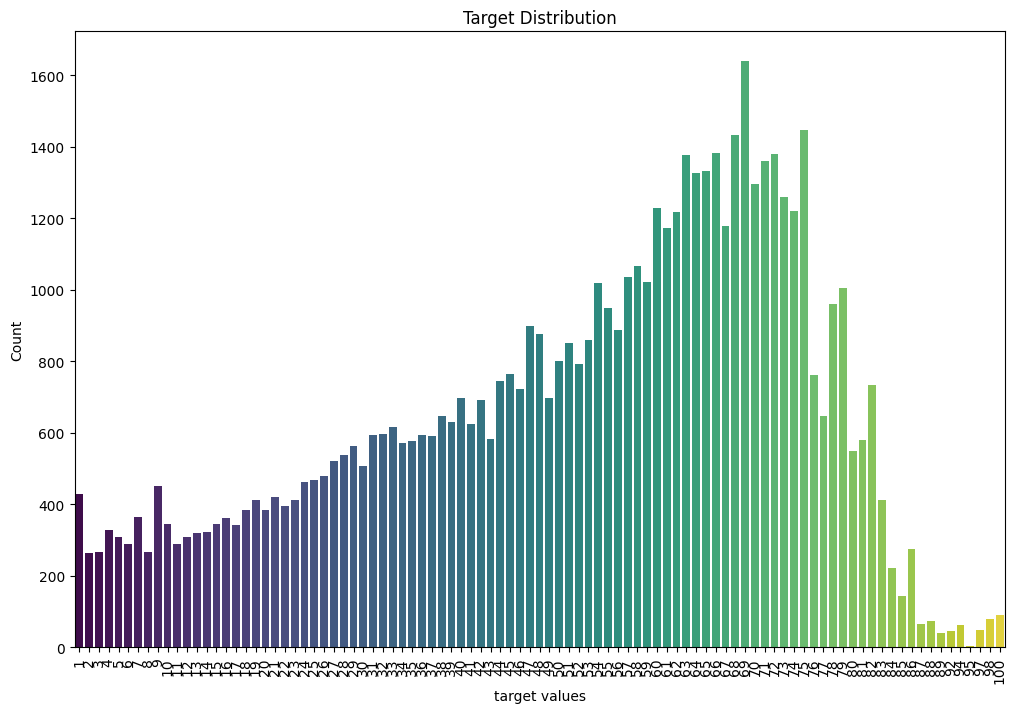

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

class_bal = y.value_counts(normalize=True)
class_bal

# 1. Target Distribution (Class Balance)
plt.figure(figsize=(12, 8))
sns.countplot(data=train_df, x='target', hue='target', palette='viridis', legend=False)
plt.title("Target Distribution")
plt.xlabel("target values")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

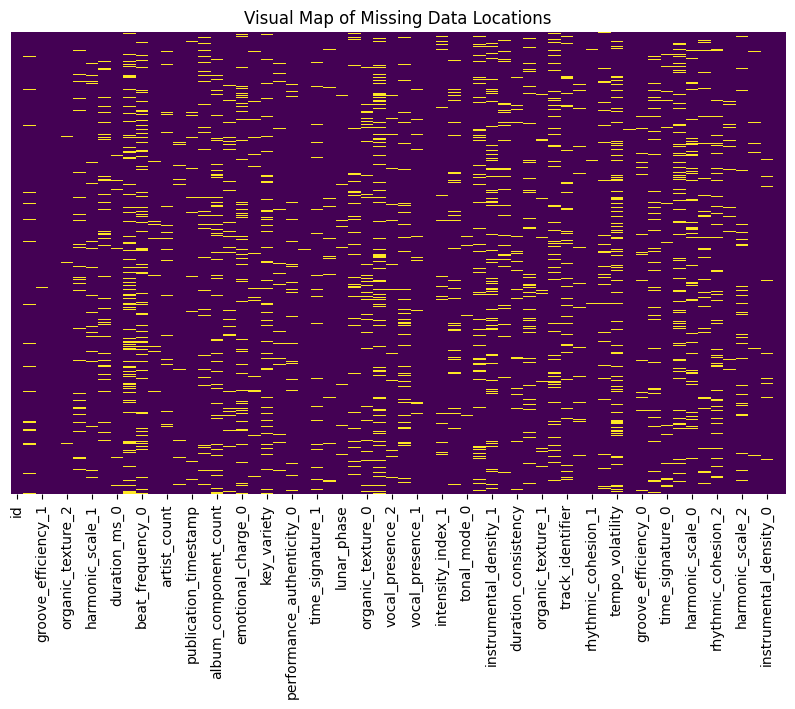

In [8]:
# Plots a heatmap where black is data, and yellow/white are missing values
plt.figure(figsize=(10, 6))
sns.heatmap(train_df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Visual Map of Missing Data Locations")
plt.show()

In [9]:
numerical_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
numerical_features

['emotional_charge_2',
 'groove_efficiency_1',
 'beat_frequency_1',
 'organic_texture_2',
 'harmonic_scale_1',
 'intensity_index_0',
 'duration_ms_0',
 'album_name_length',
 'beat_frequency_0',
 'beat_frequency_2',
 'artist_count',
 'album_component_count',
 'emotional_charge_1',
 'emotional_charge_0',
 'tonal_mode_2',
 'key_variety',
 'performance_authenticity_2',
 'performance_authenticity_0',
 'time_signature_1',
 'duration_ms_2',
 'instrumental_density_2',
 'organic_texture_0',
 'vocal_presence_2',
 'tonal_mode_1',
 'vocal_presence_1',
 'vocal_presence_0',
 'intensity_index_1',
 'organic_immersion_0',
 'tonal_mode_0',
 'groove_efficiency_2',
 'instrumental_density_1',
 'organic_immersion_2',
 'duration_consistency',
 'organic_texture_1',
 'rhythmic_cohesion_0',
 'emotional_resonance_1',
 'rhythmic_cohesion_1',
 'performance_authenticity_1',
 'tempo_volatility',
 'organic_immersion_1',
 'groove_efficiency_0',
 'emotional_resonance_2',
 'time_signature_0',
 'duration_ms_1',
 'harmoni

In [10]:
X[numerical_features].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61609 entries, 0 to 61608
Data columns (total 51 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   emotional_charge_2          59167 non-null  float64
 1   groove_efficiency_1         61429 non-null  float64
 2   beat_frequency_1            61223 non-null  float64
 3   organic_texture_2           61226 non-null  float64
 4   harmonic_scale_1            58304 non-null  float64
 5   intensity_index_0           55638 non-null  float64
 6   duration_ms_0               60320 non-null  float64
 7   album_name_length           52015 non-null  float64
 8   beat_frequency_0            51878 non-null  float64
 9   beat_frequency_2            59843 non-null  float64
 10  artist_count                58348 non-null  float64
 11  album_component_count       57246 non-null  float64
 12  emotional_charge_1          57595 non-null  float64
 13  emotional_charge_0          555

In [11]:
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer

num_features = train_df[numerical_features].copy()
imp_median = SimpleImputer(missing_values=np.nan, strategy='median')

mi_scores = mutual_info_classif(imp_median.fit_transform(num_features), y)
mi_scores

array([2.24452705, 2.34149504, 2.2797887 , 1.80682149, 0.08041232,
       1.28425343, 2.27223386, 0.25175705, 1.89886369, 2.22283212,
       0.0163965 , 0.27792496, 2.18105612, 2.0796163 , 0.00575221,
       0.01026697, 1.21429649, 1.30007762, 0.02150314, 2.27886731,
       1.09789187, 1.666813  , 1.41420765, 0.00551708, 1.46158002,
       1.48503453, 1.35141523, 2.20492986, 0.01871753, 2.1026924 ,
       1.02043839, 2.13902304, 2.22506782, 1.74434193, 1.1550521 ,
       1.42801247, 1.28916408, 1.21050238, 1.89503838, 2.36299937,
       2.28269689, 1.36290926, 0.03247469, 1.93611963, 0.06559464,
       0.02658739, 1.17761618, 1.45902866, 0.0802339 , 1.40175959,
       1.23140024])

In [12]:
mi_scores = mutual_info_classif(imp_median.fit_transform(num_features), y)
num_mi = pd.Series(mi_scores, index=num_features.columns).sort_values(ascending=False)
num_mi

organic_immersion_1           2.363262
groove_efficiency_1           2.341958
groove_efficiency_0           2.281914
beat_frequency_1              2.280486
duration_ms_2                 2.278223
duration_ms_0                 2.272755
emotional_charge_2            2.244749
duration_consistency          2.225196
beat_frequency_2              2.222701
organic_immersion_0           2.203884
emotional_charge_1            2.182711
organic_immersion_2           2.138570
groove_efficiency_2           2.102702
emotional_charge_0            2.079906
duration_ms_1                 1.936968
tempo_volatility              1.896198
beat_frequency_0              1.892866
organic_texture_2             1.807358
organic_texture_1             1.739954
organic_texture_0             1.664052
vocal_presence_0              1.486071
vocal_presence_1              1.464568
emotional_resonance_0         1.457071
emotional_resonance_1         1.432027
vocal_presence_2              1.410440
intensity_index_2        

In [13]:
numerical_features = num_mi.head(10).index.astype(str).tolist()

In [14]:
X[numerical_features].isnull().sum()/len(X[numerical_features]) *100

organic_immersion_1     0.223993
groove_efficiency_1     0.292165
groove_efficiency_0     2.395754
beat_frequency_1        0.626532
duration_ms_2           1.830901
duration_ms_0           2.092227
emotional_charge_2      3.963707
duration_consistency    4.994400
beat_frequency_2        2.866464
organic_immersion_0     6.237725
dtype: float64

In [15]:
categorical_features = X.select_dtypes(include=['object']).columns.tolist()
categorical_features

['composition_label_0',
 'composition_label_1',
 'publication_timestamp',
 'weekday_of_release',
 'season_of_release',
 'lunar_phase',
 'creator_collective',
 'composition_label_2',
 'track_identifier']

In [16]:
X[categorical_features].describe()

,composition_label_0,composition_label_1,publication_timestamp,weekday_of_release,season_of_release,lunar_phase,creator_collective,composition_label_2,track_identifier
count,58660,60149,60101,56551,61136,60608,52695,57146,57173
unique,21709,22930,6061,7,4,4,15139,22169,22991
top,Intro,Refrigerator Door,2021-09-03,Friday,summer,waning,"Various Artists,",Even Though I'm Leaving,Certified Lover Boy
freq,1640,109,540,27479,16140,15266,1735,100,94


In [17]:
categorical_features = ['weekday_of_release', 'season_of_release', 'lunar_phase']

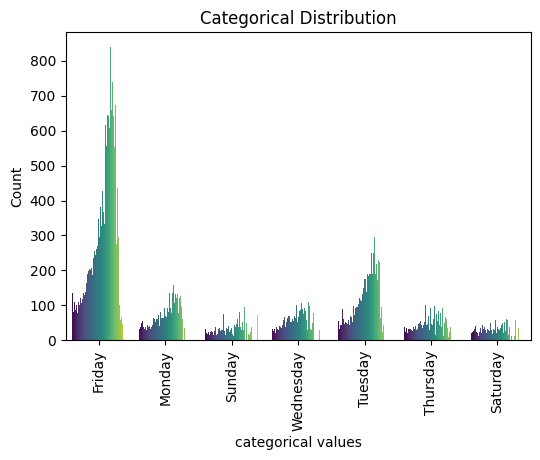

In [18]:
# 1. Target Distribution (Class Balance)
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='weekday_of_release', hue='target', palette='viridis', legend=False)
plt.title("Categorical Distribution")
plt.xlabel("categorical values")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

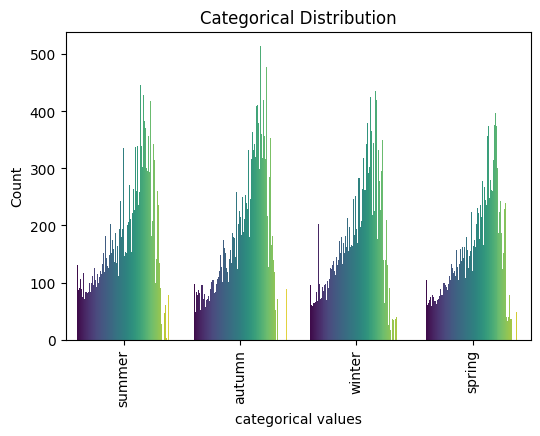

In [19]:
# 1. Target Distribution (Class Balance)
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='season_of_release', hue='target', palette='viridis', legend=False)
plt.title("Categorical Distribution")
plt.xlabel("categorical values")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

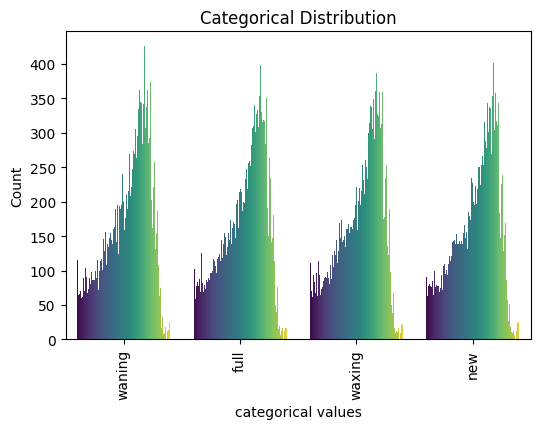

In [20]:
# 1. Target Distribution (Class Balance)
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='lunar_phase', hue='target', palette='viridis', legend=False)
plt.title("Categorical Distribution")
plt.xlabel("categorical values")
plt.xticks(rotation=90)
plt.ylabel("Count")
plt.show()

In [21]:
X[categorical_features].isnull().sum()/len(X[categorical_features]) *100

weekday_of_release    8.209839
season_of_release     0.767745
lunar_phase           1.624763
dtype: float64

In [22]:
selected_X = pd.concat([train_df[categorical_features], train_df[numerical_features]], axis=1)
selected_X

,weekday_of_release,season_of_release,lunar_phase,organic_immersion_1,groove_efficiency_1,groove_efficiency_0,beat_frequency_1,duration_ms_2,duration_ms_0,emotional_charge_2,duration_consistency,beat_frequency_2,organic_immersion_0
0,Friday,summer,waning,0.307521,1.169231,1.150146,80.018,189853.0,154586.0,0.482850,15204.423983,162.045,0.255067
1,Monday,summer,waning,0.339768,1.321321,NaN,147.966,123272.0,46874.0,0.267862,45592.954911,125.964,NaN
2,NaN,autumn,full,0.062464,1.285319,1.270758,142.980,302686.0,264665.0,0.242606,38309.603777,134.403,1.962932
3,Friday,autumn,full,0.067538,1.279435,1.145485,123.063,187126.0,209208.0,0.426400,13345.980827,107.936,0.085427
4,NaN,winter,waxing,0.112618,0.974906,1.124836,132.722,6413.0,215346.0,0.000000,110199.561452,0.000,0.405568
...,...,...,...,...,...,...,...,...,...,...,...,...,...
61604,Friday,winter,waxing,0.959694,0.809917,0.691834,90.017,240432.0,218490.0,0.261387,23496.831574,92.014,1.325506
61605,NaN,summer,waxing,1.530589,1.185022,0.889752,122.973,142186.0,259746.0,0.585648,48023.116399,124.932,NaN
61606,Sunday,summer,waxing,2.030795,0.469714,0.632212,121.045,30253.0,79093.0,0.112203,52381.481480,150.260,0.757975
61607,Friday,winter,waning,0.353800,1.486339,1.866370,95.390,207133.0,208906.0,0.438699,16053.272612,99.048,0.731171


In [23]:
from sklearn.pipeline import Pipeline
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

num_transformer = Pipeline(steps=[
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

In [24]:
from sklearn.compose import ColumnTransformer

numerical_features = [str(col) for col in numerical_features]
categorical_features = [str(col) for col in categorical_features]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_features),
        ('cat', cat_transformer, categorical_features)
    ]
)

{'regressor__n_estimators': 300,
 'regressor__min_samples_split': 10,
 'regressor__max_features': 1.0,
 'regressor__max_depth': None}

In [25]:
from sklearn.ensemble import RandomForestRegressor

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=300, 
        min_samples_split=10, 
        max_features=1.0, 
        max_depth=None))
])

In [26]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [27]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['organic_immersion_1',
                                                   'groove_efficiency_1',
                                                   'groove_efficiency_0',
                                                   'beat_frequency_1',
                                                   'duration_ms_2',
                                                   'duration_ms_0',
                                                   'emotional_charge_2',
                                                   'duration_consistency',
                                                   'beat_frequency_2',
                                                   'organic_immersion_0']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='Missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['weekday_of_release',
                                                   'season_of_release',
                                                   'lunar_phase'])])),
                ('regressor',
                 RandomForestRegressor(min_samples_split=10,
                                       n_estimators=300))])

In [28]:
y_pred = model.predict(X_val)

In [29]:
y_pred.size

12322

In [30]:
y_val

31893    41
11527    98
49596    66
37300    63
38601    25
         ..
35039    60
23893    73
25527    31
58409    74
16946    57
Name: target, Length: 12322, dtype: int64

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse = mean_squared_error(y_val, y_pred)

rmse = np.sqrt(mse)

mae = mean_absolute_error(y_val, y_pred)

r2 = r2_score(y_val, y_pred)

print("--- IterativeImputer Model Evaluation ---")
print(f"Validation MSE:  {mse:.4f}")
print(f"Validation RMSE: {rmse:.4f}")
print(f"Validation MAE:  {mae:.4f}")
print(f"Validation R2:   {r2:.4f}")

--- IterativeImputer Model Evaluation ---
Validation MSE:  132.2005
Validation RMSE: 11.4978
Validation MAE:  6.4839
Validation R2:   0.7162


Starting Feature Selection Evaluation...
Testing top 10 features...
  -> RMSE with 10 features: 11.5481
Testing top 20 features...
  -> RMSE with 20 features: 11.3040
Testing top 30 features...
  -> RMSE with 30 features: 11.1559
Testing top 40 features...
  -> RMSE with 40 features: 10.8163
Testing top 51 features...
  -> RMSE with 51 features: 10.8160


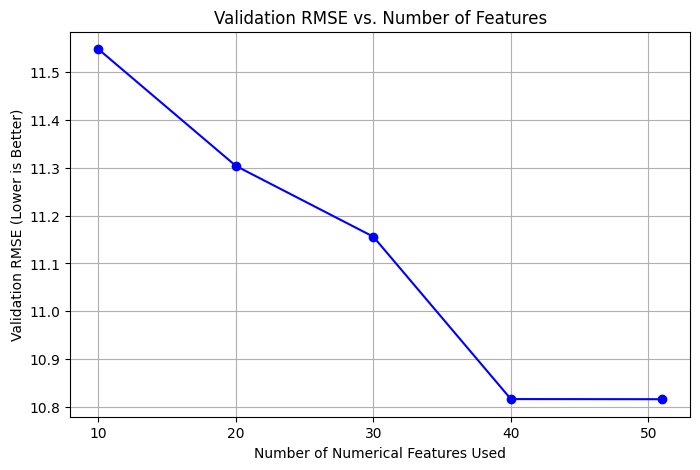

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import numpy as np

# Define the steps we want to test
feature_counts = [10, 20, 30, 40, len(num_mi)]
rmse_scores = []

print("Starting Feature Selection Evaluation...")

for k in feature_counts:
    print(f"Testing top {k} features...")
    
    # 1. Select the top 'k' numerical features based on your MI scores
    current_num_features = num_mi.head(k).index.astype(str).tolist()
    
    # 2. Update the preprocessor with the current subset of features
    current_preprocessor = ColumnTransformer(
        transformers=[
            ('num', num_transformer, current_num_features), # Using your KNN imputer
            ('cat', cat_transformer, categorical_features)
        ])
    
    # 3. Build the temporary model
    temp_model = Pipeline(steps=[
        ('preprocessor', current_preprocessor),
        ('regressor', RandomForestRegressor(
            n_estimators=100, # Lowered to 100 just to speed up this loop!
            min_samples_split=10, 
            n_jobs=-1,
            random_state=42)) 
    ])
    
    # 4. Train and evaluate
    temp_model.fit(X_train, y_train)
    preds = temp_model.predict(X_val)
    
    # Calculate RMSE and store it
    current_rmse = np.sqrt(mean_squared_error(y_val, preds))
    rmse_scores.append(current_rmse)
    print(f"  -> RMSE with {k} features: {current_rmse:.4f}")

# 5. Plot the results for your report
plt.figure(figsize=(8, 5))
plt.plot(feature_counts, rmse_scores, marker='o', linestyle='-', color='b')
plt.title('Validation RMSE vs. Number of Features')
plt.xlabel('Number of Numerical Features Used')
plt.ylabel('Validation RMSE (Lower is Better)')
plt.grid(True)
plt.show()

In [33]:
y_pred = model.predict(test_df.drop('id', axis=1))

In [34]:
submission_df = pd.DataFrame({
    'id': test_df['id'],
    'target': y_pred
})
submission_df.to_csv('submission1.csv', index=False)
submission_df.head()

,id,target
0,25174,48.092165
1,38453,68.649265
2,29013,68.100683
3,57463,76.000000
4,51264,48.025170
